In [1]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

from pathlib import Path

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [2]:
# ============================================================
# 2. LOAD THE SAVED MODEL PACKAGE
# ============================================================
# The saved model package contains:
#
# pipeline:
# The complete preprocessing and Logistic Regression pipeline.
#
# metadata:
# Feature names, class mappings, hyperparameters and
# evaluation results.

MODEL_PATH = Path(
    "../backend/models/restaurant_feasibility_pipeline.joblib"
)

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model file not found at: {MODEL_PATH.resolve()}"
    )

model_package = joblib.load(
    MODEL_PATH
)

loaded_pipeline = model_package[
    "pipeline"
]

loaded_metadata = model_package[
    "metadata"
]

print("Final model loaded successfully.")
print("Model:", loaded_metadata["model_name"])

Final model loaded successfully.
Model: Logistic Regression


In [3]:
# ============================================================
# 3. EXTRACT MODEL INFORMATION FROM METADATA
# ============================================================

MODEL_FEATURES = loaded_metadata[
    "model_features"
]

NUMERIC_FEATURES = loaded_metadata[
    "numeric_features"
]

CATEGORICAL_FEATURES = loaded_metadata[
    "categorical_features"
]

LABEL_MAPPING = {
    int(class_value): class_name
    for class_value, class_name
    in loaded_metadata["label_mapping"].items()
}

print("Required input features:")
for feature in MODEL_FEATURES:
    print("-", feature)

print("\nClass mapping:")
print(LABEL_MAPPING)

Required input features:
- bank_count_500m
- bus_stop_count_500m
- cinema_count_500m
- clinic_count_500m
- college_count_500m
- hospital_count_500m
- museum_count_500m
- office_count_500m
- parking_space_count_500m
- recreation_count_500m
- retail_count_500m
- school_count_500m
- temple_count_500m
- nearest_restaurant_m
- competitor_count_500m
- avg_restaurant_rating_500m
- avg_review_ratings_500m
- search_area

Class mapping:
{0: 'Low', 1: 'Moderate', 2: 'High'}


In [4]:
# ============================================================
# 4. DISPLAY SAVED MODEL INFORMATION
# ============================================================

model_summary = {
    "Model": loaded_metadata["model_name"],
    "CV Macro F1": loaded_metadata[
        "cross_validation_macro_f1"
    ],
    "Test Accuracy": loaded_metadata[
        "test_accuracy"
    ],
    "Test Macro F1": loaded_metadata[
        "test_macro_f1"
    ],
    "Test Macro Precision": loaded_metadata[
        "test_macro_precision"
    ],
    "Test Macro Recall": loaded_metadata[
        "test_macro_recall"
    ]
}

model_summary_df = pd.DataFrame(
    [model_summary]
)

display(
    model_summary_df.round(4)
)

,Model,CV Macro F1,Test Accuracy,Test Macro F1,Test Macro Precision,Test Macro Recall
0,Logistic Regression,0.993,0.9952,0.995,0.995,0.995


In [5]:
# ============================================================
# 5. LOAD THE LABELLED DATASET FOR FEATURE IMPORTANCE
# ============================================================
# The dataset is required only for model interpretation.
#
# The saved model itself does not require the training dataset
# when making predictions for a new location.

DATA_PATH = Path(
    "../data/processed/dataset_labelled_with_score.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}"
    )

df = pd.read_csv(
    DATA_PATH
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (4172, 61)


In [6]:
# ============================================================
# 6. PREPARE FEATURES AND TARGET FOR INTERPRETATION
# ============================================================
# The same raw model features used during training are selected.
#
# The target is encoded using:
# Low = 0
# Moderate = 1
# High = 2

X_interpretation = df[
    MODEL_FEATURES
].copy()

target_text = (
    df["feasibility_label"]
    .astype("string")
    .str.strip()
    .str.title()
)

TARGET_ENCODING = {
    "Low": 0,
    "Moderate": 1,
    "High": 2
}

y_interpretation = (
    target_text
    .map(TARGET_ENCODING)
)

if y_interpretation.isna().any():
    raise ValueError(
        "Invalid or missing feasibility labels were found."
    )

y_interpretation = y_interpretation.astype(
    "int64"
)

print("Interpretation feature shape:", X_interpretation.shape)
print("Interpretation target shape:", y_interpretation.shape)

Interpretation feature shape: (4172, 18)
Interpretation target shape: (4172,)


In [7]:
# ============================================================
# 7. CREATE AN INTERPRETATION TEST SET
# ============================================================
# A stratified split is created so feature importance is
# calculated using unseen observations rather than the full
# training dataset.

from sklearn.model_selection import train_test_split

_, X_importance_test, _, y_importance_test = train_test_split(
    X_interpretation,
    y_interpretation,
    test_size=0.20,
    random_state=42,
    stratify=y_interpretation
)

print(
    "Feature importance test shape:",
    X_importance_test.shape
)

Feature importance test shape: (835, 18)


In [8]:
# ============================================================
# 8. CALCULATE PERMUTATION FEATURE IMPORTANCE
# ============================================================
# Permutation importance measures how much Macro F1 decreases
# when one feature is randomly shuffled.
#
# Larger positive values indicate greater predictive influence.

permutation_result = permutation_importance(
    estimator=loaded_pipeline,
    X=X_importance_test,
    y=y_importance_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

print("Permutation feature importance calculated.")

Permutation feature importance calculated.


In [9]:
# ============================================================
# 9. CREATE FEATURE IMPORTANCE TABLE
# ============================================================

feature_importance_df = pd.DataFrame({
    "Feature": X_importance_test.columns,
    "Importance Mean": permutation_result.importances_mean,
    "Importance Std": permutation_result.importances_std
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance_df.round(6)
)

,Feature,Importance Mean,Importance Std
0,museum_count_500m,0.117983,0.007334
1,cinema_count_500m,0.104755,0.007847
2,bus_stop_count_500m,0.090567,0.004603
3,parking_space_count_500m,0.071787,0.011716
4,bank_count_500m,0.061640,0.007947
5,college_count_500m,0.060207,0.007725
6,office_count_500m,0.053370,0.008463
7,temple_count_500m,0.046237,0.005100
8,clinic_count_500m,0.045243,0.006896
9,hospital_count_500m,0.032754,0.004515


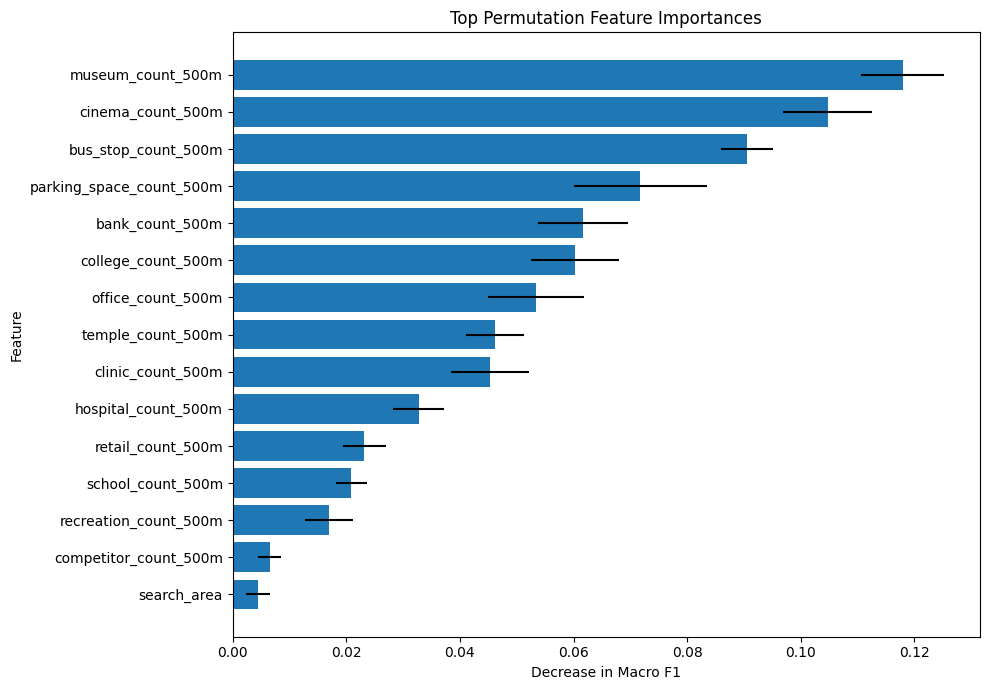

In [10]:
# ============================================================
# 10. PLOT THE TOP FEATURE IMPORTANCES
# ============================================================

TOP_FEATURE_COUNT = min(
    15,
    len(feature_importance_df)
)

top_feature_importance_df = (
    feature_importance_df
    .head(TOP_FEATURE_COUNT)
    .sort_values(
        by="Importance Mean",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_feature_importance_df["Feature"],
    top_feature_importance_df["Importance Mean"],
    xerr=top_feature_importance_df["Importance Std"]
)

plt.title(
    "Top Permutation Feature Importances"
)

plt.xlabel(
    "Decrease in Macro F1"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 11. SAVE FEATURE IMPORTANCE RESULTS
# ============================================================

OUTPUT_DIRECTORY = Path(
    "../outputs/model_results"
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

FEATURE_IMPORTANCE_PATH = (
    OUTPUT_DIRECTORY
    / "feature_importance.csv"
)

feature_importance_df.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False
)

print(
    "Feature importance saved to:",
    FEATURE_IMPORTANCE_PATH.resolve()
)

Feature importance saved to: C:\Users\mausa\Desktop\minor project\minor_prj\outputs\model_results\feature_importance.csv


In [12]:
# ============================================================
# 12. DEFINE THE PREDICTION FUNCTION
# ============================================================
# The function receives raw location features.
#
# The loaded pipeline automatically performs:
#
# - Median imputation
# - Numerical normalization
# - One-hot encoding
# - Logistic Regression prediction
# - Probability prediction

def predict_location_feasibility(location_features):
    """
    Predict restaurant-location feasibility.

    Parameters
    ----------
    location_features : dict
        Raw location features for one selected location.

    Returns
    -------
    dict
        Predicted encoded class, class label and probabilities.
    """

    missing_features = [
        feature
        for feature in MODEL_FEATURES
        if feature not in location_features
    ]

    if missing_features:
        raise ValueError(
            "Missing required features:\n"
            + "\n".join(
                f"- {feature}"
                for feature in missing_features
            )
        )

    location_df = pd.DataFrame(
        [location_features],
        columns=MODEL_FEATURES
    )

    predicted_class = int(
        loaded_pipeline.predict(
            location_df
        )[0]
    )

    predicted_probabilities = (
        loaded_pipeline.predict_proba(
            location_df
        )[0]
    )

    classifier_classes = (
        loaded_pipeline
        .named_steps["classifier"]
        .classes_
    )

    probability_output = {
        LABEL_MAPPING[int(class_value)]: round(
            float(probability),
            4
        )
        for class_value, probability
        in zip(
            classifier_classes,
            predicted_probabilities
        )
    }

    return {
        "predicted_class": predicted_class,
        "predicted_label": LABEL_MAPPING[
            predicted_class
        ],
        "probabilities": probability_output
    }

In [13]:
# ============================================================
# 13. PREPARE FEATURES FOR A SELECTED MAP LOCATION
# ============================================================
# These are demonstration values.
#
# Later, the values should be generated dynamically by counting
# POIs within 500 meters of the selected latitude and longitude.

selected_location_features = {
    "bank_count_500m": 8,
    "bus_stop_count_500m": 12,
    "cinema_count_500m": 1,
    "clinic_count_500m": 7,
    "college_count_500m": 3,
    "hospital_count_500m": 2,
    "museum_count_500m": 0,
    "office_count_500m": 25,
    "parking_space_count_500m": 5,
    "recreation_count_500m": 4,
    "retail_count_500m": 30,
    "school_count_500m": 6,
    "temple_count_500m": 5,
    "nearest_restaurant_m": 75.5,
    "competitor_count_500m": 18,
    "avg_restaurant_rating_500m": 4.1,
    "avg_review_ratings_500m": 245.0,
    "search_area": "Baneshwor"
}

selected_location_df = pd.DataFrame(
    [selected_location_features]
)

display(
    selected_location_df
)

,bank_count_500m,bus_stop_count_500m,cinema_count_500m,clinic_count_500m,college_count_500m,hospital_count_500m,museum_count_500m,office_count_500m,parking_space_count_500m,recreation_count_500m,retail_count_500m,school_count_500m,temple_count_500m,nearest_restaurant_m,competitor_count_500m,avg_restaurant_rating_500m,avg_review_ratings_500m,search_area
0,8,12,1,7,3,2,0,25,5,4,30,6,5,75.5,18,4.1,245.0,Baneshwor


In [14]:
print(
    sorted(
        df["search_area"]
        .dropna()
        .unique()
    )
)

['Baneshwor', 'Bhaktapur durbar square', 'Boudha stupa', 'Durbar Marg', 'Kirtipur', 'Koteshwor', 'New Road', 'Patan durbar square', 'Pulchowk']


In [15]:
# ============================================================
# 14. PREDICT THE SELECTED LOCATION
# ============================================================

prediction_result = predict_location_feasibility(
    selected_location_features
)

print(
    "Predicted feasibility:",
    prediction_result["predicted_label"]
)

print(
    "Encoded class:",
    prediction_result["predicted_class"]
)

print("\nPredicted probabilities:")

for class_name, probability in (
    prediction_result["probabilities"].items()
):
    print(
        f"{class_name}: {probability:.4f}"
    )

Predicted feasibility: Moderate
Encoded class: 1

Predicted probabilities:
Low: 0.0000
Moderate: 1.0000
High: 0.0000


In [16]:
# ============================================================
# 15. DISPLAY PROBABILITIES AS A TABLE
# ============================================================

probability_df = pd.DataFrame({
    "Feasibility Class": (
        prediction_result[
            "probabilities"
        ].keys()
    ),
    "Probability": (
        prediction_result[
            "probabilities"
        ].values()
    )
})

probability_df["Percentage"] = (
    probability_df["Probability"] * 100
).round(2)

probability_df = (
    probability_df
    .sort_values(
        by="Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    probability_df
)

,Feasibility Class,Probability,Percentage
0,Moderate,1.0,100.0
1,Low,0.0,0.0
2,High,0.0,0.0


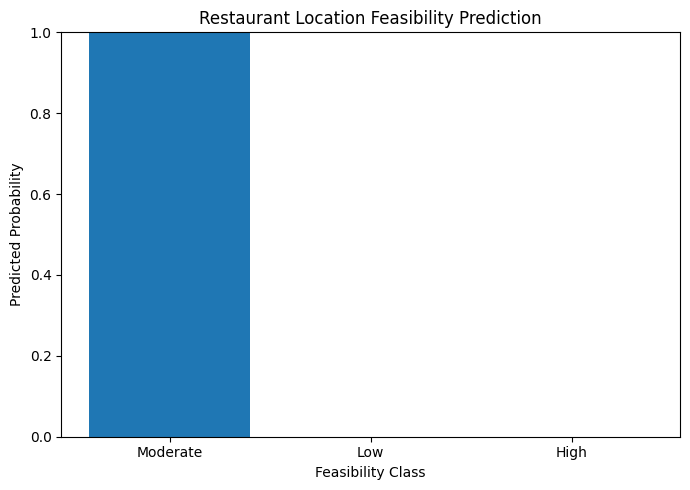

In [17]:
# ============================================================
# 16. PLOT PREDICTED PROBABILITIES
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    probability_df["Feasibility Class"],
    probability_df["Probability"]
)

plt.title(
    "Restaurant Location Feasibility Prediction"
)

plt.xlabel(
    "Feasibility Class"
)

plt.ylabel(
    "Predicted Probability"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# 17. TEST THE SAVED MODEL ON AN EXISTING OBSERVATION
# ============================================================
# This verifies that the loaded model can predict an observation
# directly from the labelled dataset.

sample_index = X_importance_test.index[0]

sample_features = (
    X_importance_test
    .loc[sample_index]
    .to_dict()
)

sample_prediction = predict_location_feasibility(
    sample_features
)

actual_class = int(
    y_importance_test.loc[sample_index]
)

actual_label = LABEL_MAPPING[
    actual_class
]

print(
    "Actual label:",
    actual_label
)

print(
    "Predicted label:",
    sample_prediction["predicted_label"]
)

print(
    "Probabilities:",
    sample_prediction["probabilities"]
)

Actual label: Low
Predicted label: Low
Probabilities: {'Low': 1.0, 'Moderate': 0.0, 'High': 0.0}


In [19]:
print(model_package["metadata"])

{'model_name': 'Logistic Regression', 'model_features': ['bank_count_500m', 'bus_stop_count_500m', 'cinema_count_500m', 'clinic_count_500m', 'college_count_500m', 'hospital_count_500m', 'museum_count_500m', 'office_count_500m', 'parking_space_count_500m', 'recreation_count_500m', 'retail_count_500m', 'school_count_500m', 'temple_count_500m', 'nearest_restaurant_m', 'competitor_count_500m', 'avg_restaurant_rating_500m', 'avg_review_ratings_500m', 'search_area'], 'numeric_features': ['bank_count_500m', 'bus_stop_count_500m', 'cinema_count_500m', 'clinic_count_500m', 'college_count_500m', 'hospital_count_500m', 'museum_count_500m', 'office_count_500m', 'parking_space_count_500m', 'recreation_count_500m', 'retail_count_500m', 'school_count_500m', 'temple_count_500m', 'nearest_restaurant_m', 'competitor_count_500m', 'avg_restaurant_rating_500m', 'avg_review_ratings_500m'], 'categorical_features': ['search_area'], 'label_mapping': {0: 'Low', 1: 'Moderate', 2: 'High'}, 'best_hyperparameters':